0.031415926535897934
[[ 1.66621446+0.j          0.99950656+0.03141076j  0.        +0.j
  ...  0.        +0.j          0.        +0.j
   0.99950656-0.03141076j]
 [ 0.99950656-0.03141076j -1.57475268+0.j          0.99950656+0.03141076j
  ...  0.        +0.j          0.        +0.j
   0.        +0.j        ]
 [ 0.        +0.j          0.99950656-0.03141076j  1.9456712 +0.j
  ...  0.        +0.j          0.        +0.j
   0.        +0.j        ]
 ...
 [ 0.        +0.j          0.        +0.j          0.        +0.j
  ... -0.91451271+0.j          0.99950656+0.03141076j
   0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
  ...  0.99950656-0.03141076j -2.94352338+0.j
   0.99950656+0.03141076j]
 [ 0.99950656+0.03141076j  0.        +0.j          0.        +0.j
  ...  0.        +0.j          0.99950656-0.03141076j
  -0.8499973 +0.j        ]]


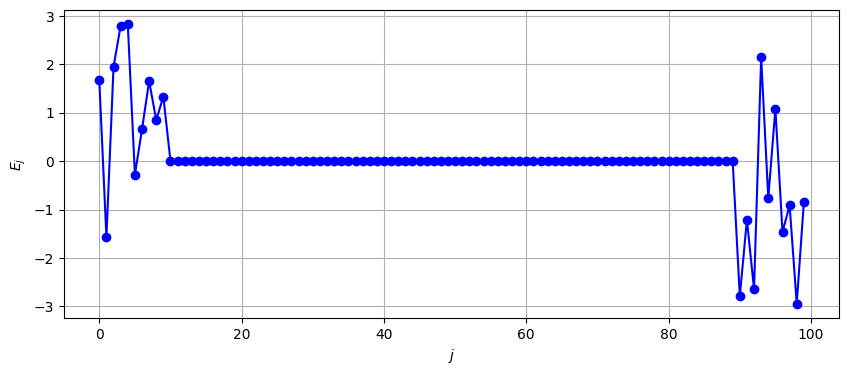

Evolution saved to qw_history.npz


In [ ]:
import numpy as np # for doing stuff with numbers
from scipy.linalg import expm # this we need for the time evolution operator
import matplotlib.pyplot as plt # added for plotting the on-site energies

np.random.seed(13) # fixed the random seed here!

##########################################
# 1. define parameters for a qw on a line 
##########################################
num_sites = 100
t_max = 150 # duration of the evolution (renamed to avoid overwriting)
num_steps = 100 # number of frames for our history
times = np.linspace(0, t_max, num_steps) # array of times
#phi = 0
phi = np.pi/float(num_sites)
print(phi)

##########################################
# 2. Laplacian matrix for a 1D line (L = D - A)
##########################################
# on-site energies
diag = 0 * np.eye(num_sites)

# random noise at the boundaries
boundary_width = 10 # number of sites at the left and right boundaries
noise_strength = 3 # amplitude of the random noise

for i in list(range(0, boundary_width)) + list(range(num_sites - boundary_width, num_sites)):
    # uniform random distribution between -noise_strength and +noise_strength
    diag[i, i] = np.random.uniform(-noise_strength, noise_strength)



# first neighbor hopping
upper_diag = np.exp(1j * phi) * np.eye(num_sites, k=1)
lower_diag = np.exp(-1j * phi) * np.eye(num_sites, k=-1)
# sum
L = diag + upper_diag + lower_diag
# add periodic boundary conditions (it becomes a ring...)
L[0,-1] = np.exp(-1j * phi)
L[-1,0] = np.exp(1j * phi)
# check 
print(L)

# Plot the on-site energies so you can check what's going on
plt.figure(figsize=(10, 4))
plt.plot(np.diag(diag).real, marker='o', linestyle='-', color='b')
plt.xlabel("$j$")
plt.ylabel("$E_j$")
plt.grid(True)
plt.show()

##########################################
# 3. initialization of the state
##########################################

psi_0 = np.zeros(num_sites, dtype=complex)
psi_0[int(num_sites/2)] = 1.0 # start at the very center
#psi_0[0] = 1.0

##########################################
# 4. time evolution (time-indep. H)
##########################################
gamma = 1.0 # hopping rate
H = gamma * L

# empty matrix to store the history: rows = time steps, cols = sites
history_psi = np.zeros((num_steps, num_sites), dtype=complex)

for i, current_t in enumerate(times):
    U = expm(-1j * H * current_t) # exp(-iHt/hbar), hbar set to 1
    psi_t = np.dot(U,psi_0) # matrix multiplication
    history_psi[i, :] = psi_t

##########################################
# 5. probabilities calculation 
##########################################
probabilities_history = np.abs(history_psi) ** 2 
# no need to project it: this is done INTERNALLY

##########################################
# 6. save data to file
##########################################
# saving probabilities, times, and num_sites into a compressed .npz file
np.savez('qw_history.npz', probs=probabilities_history, times=times, num_sites=num_sites, boundary_width=boundary_width)
print("Evolution saved to qw_history.npz")